### Análisis de las discrepacias en el cruzado de datos

Total de registros analizados: 32179

DISTRIBUCIÓN DEL MARGEN DE ERROR (SOFASCORE vs OPTA):

    Exactos (0 pts):   14621 jug. (45.4%)

    Desfase de 1 pts:  11662 jug. (36.2%) -> Precisión Acumulada: 81.7%

    Desfase de 2 pts:  4077 jug. (12.7%) -> Precisión Acumulada: 94.3%

    Desfase de 3 pts:  1179 jug. (3.7%) -> Precisión Acumulada: 98.0%

    Desfase de 4 pts:  419 jug. (1.3%) -> Precisión Acumulada: 99.3%

    Desfase de 5 pts:  135 jug. (0.4%) -> Precisión Acumulada: 99.7%

    Desfase de 6 pts:  52 jug. (0.2%) -> Precisión Acumulada: 99.9%

    Desfase de 7 pts:  16 jug. (0.0%) -> Precisión Acumulada: 99.9%

    Desfase de 8 pts:  11 jug. (0.0%) -> Precisión Acumulada: 100.0%

    Desfase de 9 pts:  4 jug. (0.0%) -> Precisión Acumulada: 100.0%

    Desfase de 10 pts:  2 jug. (0.0%) -> Precisión Acumulada: 100.0%

    Desfase de 14 pts:  1 jug. (0.0%) -> Precisión Acumulada: 100.0%

Nos quedamos con un dataset con las discrepancias > 5:

In [61]:
import pandas as pd
import os

ruta_csv = os.path.join("datasets", "dif+5.csv")

# Cargamos el CSV
df_discrepancias = pd.read_csv(ruta_csv)

df_discrepancias.head(10)

,Etiqueta_Jornada,Equipo,Equipo_Rival,Jugador_Fantasy,Jugador_SofaScore,Posicion,Stats_Reales,Stats_Calculados,Discrepancia,Relevo,Nota_SofaScore,Minutos_jugados,Goles,Asistencias_de_gol,Goles_en_contra_Reales,Amarillas,Rojas
0,T24-25 - J38,Leganés,Real Valladolid,Diomande,Yan Diomande,M,0,14,-14,0,9.5,63,1,1,0,0,0
1,T24-25 - J13,Real Madrid,Osasuna,Asencio,Raúl Asencio,D,0,10,-10,0,7.4,60,0,1,0,0,0
2,T23-24 - J8,Real Betis,Valencia,Assane,Assane Diao,M,0,10,-10,0,7.7,72,1,0,0,0,0
3,T23-24 - J22,Barcelona,Villarreal,Gündogan,İlkay Gündoğan,M,9,18,-9,4,9.3,90,1,1,5,0,0
4,T23-24 - J36,Celta Vigo,Athletic Club,Hugo Álvarez,Hugo Álvarez,M,0,9,-9,0,7.9,45,1,1,1,0,0
5,T23-24 - J19,Granada,Cádiz,Batalla,Augusto Batalla,G,0,9,-9,0,7.2,90,0,0,0,0,0
6,T24-25 - J21,Athletic Club,Leganés,Berenguer,Álex Berenguer,M,6,15,-9,3,7.8,73,0,0,0,0,0
7,T23-24 - J23,Villarreal,Cádiz,Baena,Alejandro Baena,M,4,12,-8,3,8.3,90,0,0,0,0,0
8,T23-24 - J36,Celta Vigo,Athletic Club,Damián,Damián Rodríguez,M,0,8,-8,0,7.3,90,0,1,1,0,0
9,T24-25 - J17,Real Valladolid,Valencia,Juma Bah,Abdulay Juma Bah,D,0,8,-8,0,8.2,90,0,0,0,0,0


### Jugadores con 0 Puntos Reales

Una de las primeras discrepancias que detecto es el caso de los jugadores que FutbolFantasy pone con 0 puntos a pesar de haber hecho un buen partido. Un claro ejemplo es Diomande, que le ponen 0 cuando Sofascore calcula 14, en el partido hizo asistencia y gol. Vamos a hacer un estudio rápido de los jugadores con stats_reales = 0.

In [67]:
df_discrepancias_ptsReales_0 = df_discrepancias[df_discrepancias['Stats_Reales'] == 0]
print(f"Cantidad de stats con 0 puntos reales: {len(df_discrepancias_ptsReales_0)}/{len(df_discrepancias)}")

Cantidad de stats con 0 puntos reales: 58/221


In [71]:
print(f"Cantidad de puntos relevo = 0 cuando tiene 0 puntos reales: {len(df_discrepancias_ptsReales_0[(df_discrepancias_ptsReales_0['Relevo'] == 0) & (df_discrepancias_ptsReales_0['Relevo'] == 0)])}/{len(df_discrepancias_ptsReales_0)}")
print(f"Cantidad de puntos relevo = 0: {len(df_discrepancias[df_discrepancias['Relevo'] == 0])}/{len(df_discrepancias)}") 
print(f"Cantidad de puntos relevo = 0 cuando tiene 0 puntos reales: {len(df_discrepancias_ptsReales_0[(df_discrepancias_ptsReales_0['Relevo'] == 0) & (df_discrepancias_ptsReales_0['Relevo'] == 0)])}/{len(df_discrepancias_ptsReales_0)}")

Cantidad de puntos relevo = 0 cuando tiene 0 puntos reales: 45/58
Cantidad de puntos relevo = 0: 53/221
Cantidad de puntos relevo = 0 cuando tiene 0 puntos reales: 45/58


En el caso de 45/58, podemos asegurar que el fantasy los tenía en su base de datos

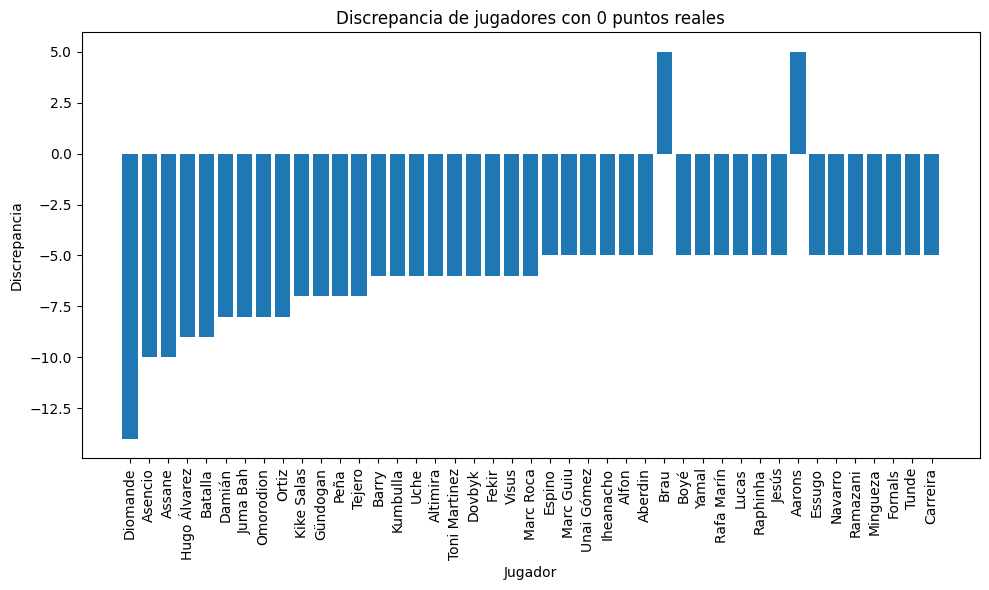

In [48]:
import matplotlib.pyplot as plt
jugadores_con_0_puntos = df_discrepancias[df_discrepancias['Stats_Reales'] == 0]
plt.figure(figsize=(10, 6))
plt.bar(jugadores_con_0_puntos['Jugador_Fantasy'], jugadores_con_0_puntos['Discrepancia'])
plt.xticks(rotation=90)
plt.xlabel('Jugador')
plt.ylabel('Discrepancia')
plt.title('Discrepancia de jugadores con 0 puntos reales')
plt.tight_layout()
plt.show()

In [49]:
jugadores_que_quiero = ["Brau", "Aarons"]

columnas = [
    "Etiqueta_Jornada", "Jugador_Fantasy", "Jugador_SofaScore", "Equipo", "Equipo_Rival", "Posicion", 
    "Stats_Reales", "Stats_Calculados", "Discrepancia", "Nota_SofaScore", 
    "Minutos_jugados", "Goles", "Asistencias_de_gol", "Goles_en_contra_Reales", 
    "Amarillas", "Rojas"
]

patron_busqueda = '|'.join(jugadores_que_quiero)

df_mi_busqueda = df_discrepancias[
    df_discrepancias['Jugador_Fantasy'].str.contains(patron_busqueda, case=False, na=False)
][columnas]

display(df_mi_busqueda)

,Etiqueta_Jornada,Jugador_Fantasy,Jugador_SofaScore,Equipo,Equipo_Rival,Posicion,Stats_Reales,Stats_Calculados,Discrepancia,Nota_SofaScore,Minutos_jugados,Goles,Asistencias_de_gol,Goles_en_contra_Reales,Amarillas,Rojas
108,T23-24 - J38,Brau,Miguel Ángel Brau,Granada,Girona FC,D,0,-5,5,6.2,30,0,0,7,0,0
169,T24-25 - J21,Aarons,Max Aarons,Valencia,Barcelona,D,0,-5,5,6.5,30,0,0,6,0,0


En ambos casos, los jugadores sufrieron goleadas, un 7-0 y un 7-1 (aunque pone 6 goles en contra). Por lo que ambos jugadores siendo defensas deberían tener puntuación negativa. Lo que también puede ser un factor clave es que era la primera vez que jugaban con el equipo y pudede que no estuvieran registrados en el fatasy.

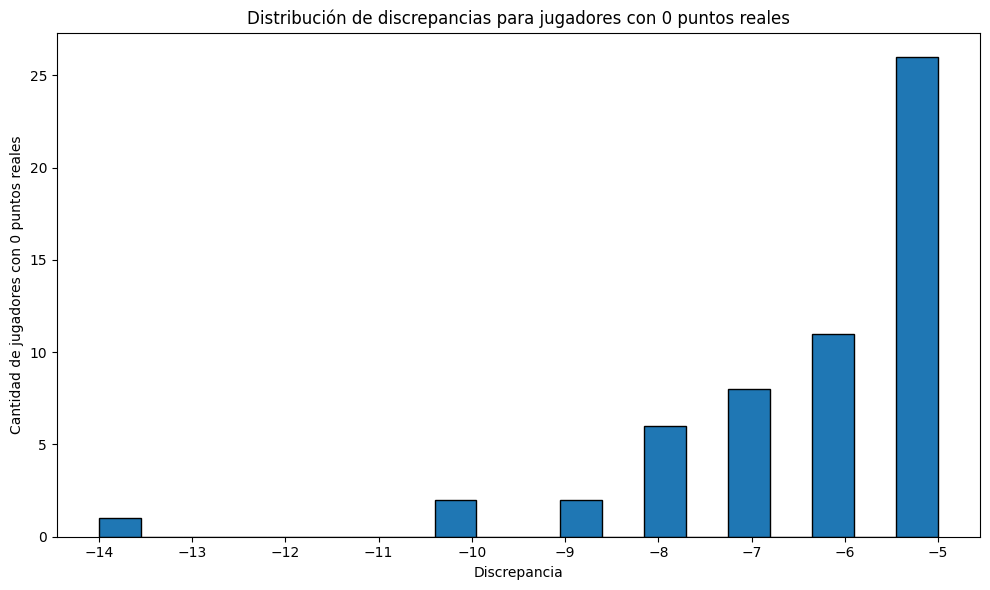

In [50]:
import matplotlib.pyplot as plt
import numpy as np

df_discrepancias = df_discrepancias[df_discrepancias['Stats_Calculados'] >= 0]

jugadores_con_0_puntos = df_discrepancias[df_discrepancias['Stats_Reales'] == 0]

plt.figure(figsize=(10, 6))
plt.hist(jugadores_con_0_puntos['Discrepancia'], bins=20, edgecolor='black')

# 🚨 LA MAGIA AQUÍ: Forzamos todos los "ticks" (marcas) del eje X
min_val = int(jugadores_con_0_puntos['Discrepancia'].min())
max_val = int(jugadores_con_0_puntos['Discrepancia'].max())
plt.xticks(np.arange(min_val, max_val + 1, 1)) 

plt.xlabel('Discrepancia')
plt.ylabel('Cantidad de jugadores con 0 puntos reales')
plt.title('Distribución de discrepancias para jugadores con 0 puntos reales')
plt.tight_layout()
plt.show()

In [51]:
condicion_cero_puntos = df_discrepancias['Stats_Reales'] == 0
condicion_tarjetas = (df_discrepancias['Amarillas'] > 0) | (df_discrepancias['Rojas'] > 0)
condicion_poco_tiempo_jugado = df_discrepancias['Minutos_jugados'] < 30
condicion_mucho_tiempo_jugado = df_discrepancias['Minutos_jugados'] >= 70
condicion_defensa = df_discrepancias['Posicion'] == 'D'
condicion_goles_contra = df_discrepancias['Goles_en_contra_Reales'] > 0
condicion_goles_asisntencias = (df_discrepancias['Goles'] > 0) | (df_discrepancias['Asistencias_de_gol'] > 0)

In [55]:
columnas = [
    "Etiqueta_Jornada", "Jugador_Fantasy", "Goles", "Asistencias_de_gol", 
    "Stats_Calculados", "Relevo", "Equipo", "Equipo_Rival", "Posicion", 
    "Minutos_jugados", "Goles_en_contra_Reales", "Amarillas", "Rojas"
]



df_ceros_reales = df_discrepancias[condicion_cero_puntos & condicion_tarjetas & condicion_poco_tiempo_jugado][columnas].copy()

df_ceros_reales = df_ceros_reales.rename(columns={
    "Asistencias_de_gol": "Asist",
    "Goles_en_contra_Reales": "Goles_Contra",
    "Stats_Calculados": "diferencia"
})

display(df_ceros_reales.sort_values(by='diferencia', ascending=False))

,Etiqueta_Jornada,Jugador_Fantasy,Goles,Asist,diferencia,Relevo,Equipo,Equipo_Rival,Posicion,Minutos_jugados,Goles_Contra,Amarillas,Rojas


Una primera hipótesis era que habría jugadores con 0 puntos por el hecho de que estarían amonestados, pero casualmente, ninguno de los jugadores que tienen 0 puntos en este dataset tienen amonestaciones

In [56]:
df_ceros_reales = df_discrepancias[condicion_cero_puntos & condicion_poco_tiempo_jugado][columnas].copy()

df_ceros_reales = df_ceros_reales.rename(columns={
    "Asistencias_de_gol": "Asist",
    "Goles_en_contra_Reales": "Goles_Contra",
    "Stats_Calculados": "diferencia"
})

display(df_ceros_reales.sort_values(by='diferencia', ascending=False))

,Etiqueta_Jornada,Jugador_Fantasy,Goles,Asist,diferencia,Relevo,Equipo,Equipo_Rival,Posicion,Minutos_jugados,Goles_Contra,Amarillas,Rojas
25,T23-24 - J15,Kike Salas,1,0,7,0,Sevilla,Villarreal,D,18,1,0,0
64,T24-25 - J3,Toni Martinez,1,0,6,0,Deportivo Alavés,Real Sociedad,F,20,1,0,0
72,T23-24 - J1,Dovbyk,1,0,6,0,Girona FC,Real Sociedad,F,26,1,0,0
90,T23-24 - J10,Marc Guiu,1,0,5,0,Barcelona,Athletic Club,F,11,0,0,0
91,T23-24 - J3,Unai Gómez,1,0,5,0,Athletic Club,Real Betis,M,24,2,0,0
179,T25-26 - J3,Ramazani,0,1,5,0,Valencia,Getafe,F,11,0,0,0


Se podría llegar a pensar que por jugar pocos minutos consiguen menos puntos y coincide con 0, pero si observamos la tabla, vemos como no tiene sentido. Todos los casos de puntos reales = 0 y que hayan jugado menos de 30min tienen o gol o asistencia, solo hay 1 defensa y recibió 1 gol en contra y ninguno de estos jugadores fueron amonestados. La diferencia más pequeña es de 5 puntos pero no tiene sentido tanta diferencia, podemos asumir que es un error de la base de datos del Fantasy, que no tenía a estos jugadores registrados todavía. Tiene sentido esta hipótesis dado que 4 de las 6 jorndas son durante el mercado de fichajes, por lo que no estarían registrados en la liga hasta poco antes del partido. En el caso de Marc Guiu y Kike Salas, doy por hecho que serán debutantes de categorias inferiores, en el caso de Marc Guiu es justamente ese el caso.

In [57]:
df_ceros_reales = df_discrepancias[condicion_cero_puntos & condicion_goles_contra & ~condicion_goles_asisntencias][columnas].copy()

df_ceros_reales = df_ceros_reales.rename(columns={
    "Asistencias_de_gol": "Asist",
    "Goles_en_contra_Reales": "Goles_Contra",
    "Stats_Calculados": "diferencia"
})

display(df_ceros_reales.sort_values(by='diferencia', ascending=False))

,Etiqueta_Jornada,Jugador_Fantasy,Goles,Asist,diferencia,Relevo,Equipo,Equipo_Rival,Posicion,Minutos_jugados,Goles_Contra,Amarillas,Rojas
22,T23-24 - J18,Gündogan,0,0,7,1,Barcelona,Almería,M,90,2,0,0
24,T23-24 - J32,Hugo Álvarez,0,0,7,0,Celta Vigo,Las Palmas,M,90,1,0,0
31,T24-25 - J11,Tejero,0,0,7,2,Espanyol,Sevilla,M,90,2,0,0
56,T24-25 - J36,Altimira,0,0,6,1,Leganés,Villarreal,M,90,3,0,0
59,T24-25 - J36,Diomande,0,0,6,0,Leganés,Villarreal,M,90,3,0,0
75,T23-24 - J37,Fekir,0,0,6,3,Real Betis,Real Sociedad,M,90,2,0,0
94,T24-25 - J3,Alfon,0,0,5,0,Celta Vigo,Villarreal,F,70,3,0,0
120,T23-24 - J21,Boyé,0,0,5,2,Granada,Atlético Madrid,F,90,1,0,0
124,T23-24 - J29,Hugo Álvarez,0,0,5,0,Celta Vigo,Sevilla,M,76,1,0,0
138,T23-24 - J1,Rafa Marín,0,0,5,0,Deportivo Alavés,Cádiz,D,90,1,0,0
